# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import levene
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import pointbiserialr

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**Observaciones:**
 - Se puede observar claramente que en ninguna de las columnas existen valores nulos.
 - La columna `date` se encuentra como tipo "object", lo cual es incorrecto, se cambiara al tipo de variable correcta que es "date".

**Conversion de columna `date` de tipo "object" a "date".**

In [ ]:
df["date"]= pd.to_datetime(df["date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


In [ ]:
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].duplicated().sum()

0

In [ ]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).


Conteo de categorías:  ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']


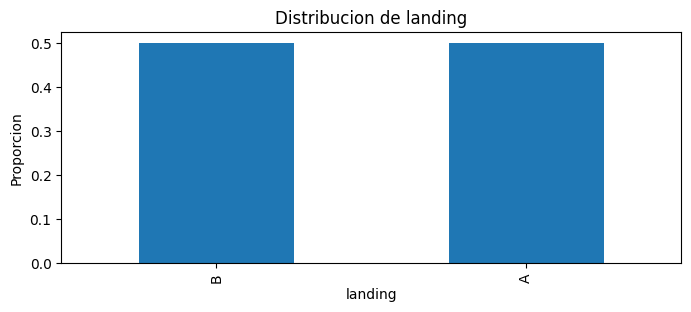

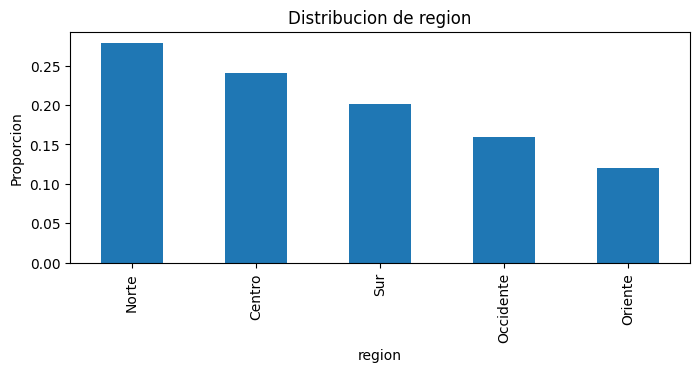

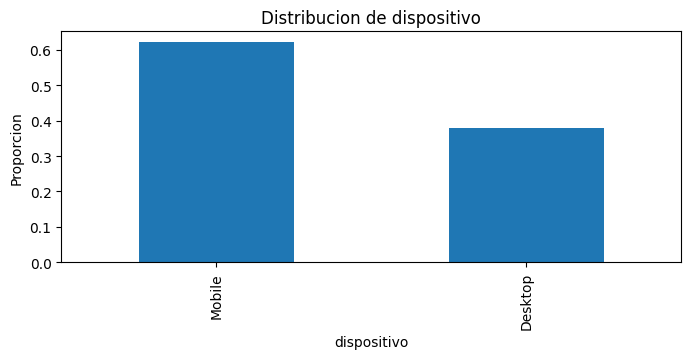

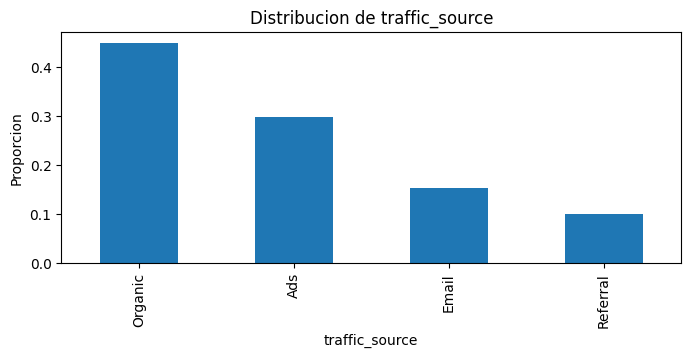

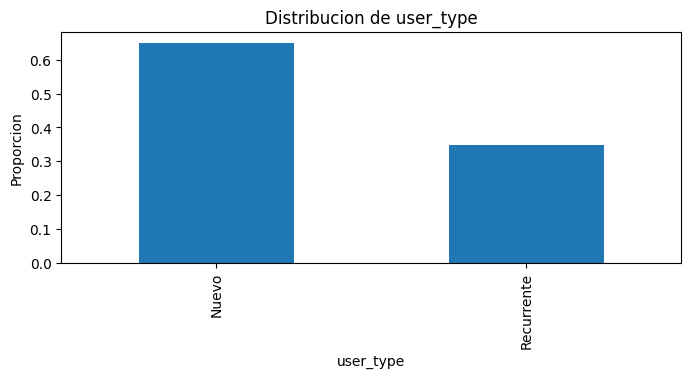

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas= [["landing", "region", "dispositivo", "traffic_source", "user_type"]]
print("\nConteo de categorías: ", ["landing", "region", "dispositivo", "traffic_source", "user_type"])
for col in ["landing", "region", "dispositivo", "traffic_source", "user_type"]:
    proporciones= df[col].value_counts(normalize= True)
    plt.figure(figsize= (8,3))
    proporciones.plot(kind= "bar")
    plt.title(f'Distribucion de {col}')
    plt.ylabel("Proporcion")
    plt.xlabel(col)
    plt.show()

**Observaciones**
- No se detectan categorias mal escritas.
- Todas las columnas tienen valores esperados

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["converted"]== 1) & (df["landing"]== "A")]["gasto"]
gasto_B = df[(df["converted"]== 1) & (df["landing"]== "B")]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
print("Cantidad de elementos por pagina")
print(f'Pagina A: {len(gasto_A)} \nPagina B: {len(gasto_B)}\n')
print(f'Gasto promedio pagina A: ${gasto_A.mean():.2f}')
print(f'Gasto promedio pagina B: ${gasto_B.mean():.2f}')

Cantidad de elementos por pagina
Pagina A: 2512 
Pagina B: 3194

Gasto promedio pagina A: $61.09
Gasto promedio pagina B: $68.75


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** "No existen diferencias estadisticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entra la pagina A y la pagina B"
- **Hipótesis alternativa (H₁):** "Existen diferencias estadisticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entre la pagina A y la pagina B"

In [ ]:
l_stat, p_value_var= levene(gasto_A, gasto_B)
print(f'Estadistico de Levene: {l_stat:.4f}')
print(f'Valor P: {p_value_var:.8f}')

alpha= 0.05
if p_value_var < alpha:
    print("\nSe rechaza hipotesis nula: hay evidencia de varianzas diferentes.")
else:
    print("\nSe acepta hipotesis nula: no hay evidencia de varianzas diferentes.")

Estadistico de Levene: 29.1765
Valor P: 0.00000007

Se rechaza hipotesis nula: hay evidencia de varianzas diferentes.


In [ ]:
# Aplicar prueba
if p_value_var < alpha:
    t_stat, p_value= ttest_ind(gasto_A, gasto_B, equal_var= False)
else:
    t_stat, p_value= ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t student: {t_stat:.4f}")
print(f"Valor p: {p_value:.8f}")

Estadístico t student: -9.4810
Valor p: 0.00000000


In [ ]:
alpha= 0.05
if p_value <= alpha:
    print("-------------------------------------------------------------------------------------------")
    print("\nExisten diferencias estadisticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entre la pagina A y la pagina B")
    print("\n--------------------------------------------------------------------------------------------")
else:
    print("-------------------------------------------------------------------------------------------")
    print("\nNo existen diferencias estadisticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entra la pagina A y la pagina B")
    print("\n--------------------------------------------------------------------------------------------")

-------------------------------------------------------------------------------------------

Existen diferencias estadisticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entre la pagina A y la pagina B

--------------------------------------------------------------------------------------------


In [ ]:
media_A= df[(df["landing"]== "A") & (df["converted"]== 1)]["gasto"].mean()
media_B= df[(df["landing"]== "B") & (df["converted"]== 1)]["gasto"].mean()
print(f'\nPagina A: {media_A}')
print(f'Pagina B: {media_B}')
if (media_A - media_B) > 0:
    print(f'\nEl gasto promedio de los convertidos en la pagina A es mayor a la pagina B por alrededor de ${(media_A - media_B):.2f} dlls.\n')
else:
    print(f'\nEl gasto promedio de los convertidos en la pagina B es mayor a la pagina A por alrededor de ${(media_B - media_A):.2f} dlls.\n')


Pagina A: 61.0865724522293
Pagina B: 68.74536005009392

El gasto promedio de los convertidos en la pagina B es mayor a la pagina A por alrededor de $7.66 dlls.



### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula (H₀).

**Interpretación de negocio:**  
“Con base en una  prueba t de dos muestras independientes, encontramos evidencia estadística de una diferencia en el gasto promedio
entre las paginas A y B.

En promedio, los usuarios que convirtieron en la pagina B gastaron más que los de la pagina A.

Este resultado se basa en una muestra de usuarios que realizaron una compra y no evalúa si la diferencia observada es suficiente para
justificar un cambio desde una perspectiva de negocio.”


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** "No existen diferencias estadisticamente significativas en la tasa de conversion entre la pagina A y la B."
- **Hipótesis alternativa (H₁):** "Existen diferencias estadisticamente significativas en la tasa de conversion entre la pagina A y la B."

In [ ]:

# Número de usuarios convertidos por página
conversiones_pagina= df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales_pagina= df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", conversiones_pagina)
print("\nTotal de usuarios por página:\n", totales_pagina)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
exitos_pagina= [conversiones_pagina["A"], conversiones_pagina["B"]]
observaciones_pagina= [totales_pagina["A"], totales_pagina["B"]]
z_stat, p_value= proportions_ztest(exitos_pagina, observaciones_pagina)

# Visualizar resultados
print(f"\nEstadístico z: {z_stat:.4f}")
print(f"Valor p: {p_value:.8f}")

alpha= 0.05
if p_value < alpha:
    print("\nExisten diferencias estadisticamente significativas en la tasa de conversion entre la pagina A y la B.")
else:
    print("\nNo existen diferencias estadisticamente significativas en la tasa de conversion entre la pagina A y la B.\n")


Estadístico z: -9.6774
Valor p: 0.00000000

Existen diferencias estadisticamente significativas en la tasa de conversion entre la pagina A y la B.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza hipotesis nula (H₀)

**Interpretación de negocio:**  
“Con base en en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre
las páginas A y B.

En particular, la página B muestra una tasa de conversión mayor que la página A.

Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una
decisión de negocio.”

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** "No existe una asociacion estadisticamente significativa entre la fuente de trafico (`trafric_source`) y la conversion (`converted`)."
- **Hipótesis alternativa (H₁):** "Existe una asociacion estadisticamente significativa entre la fuente de trafico (`trafric_source`) y la conversion (`converted`)."

In [ ]:
# Tabla de contingencia normalizada
tabla_normalizada= pd.crosstab(df["traffic_source"], df["converted"], normalize= "index")*100
tabla= pd.crosstab(df["traffic_source"], df["converted"])
print("Tabla de contingencia normalizada")
print(tabla_normalizada)
print("\n\nTabla de contingencia")
print(tabla)

Tabla de contingencia normalizada
converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


Tabla de contingencia
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected= chi2_contingency(tabla)
print(f'Estadistico chi2: {chi2_stat:.2f}')
print(f'Valor P: {p_value:.8f}')
print(f'Grados de libertad: {dof}')
print("\nFrecuencia esperada")
print(expected)

alpha= 0.05
if p_value < alpha:
    print("\nExiste una asociacion estadisticamente significativa entre la fuente de trafico (trafric_source) y la conversion (converted).")
else:
    print("\nNo Existe una asociacion estadisticamente significativa entre la fuente de trafico (trafric_source) y la conversion (converted).\n")

Estadistico chi2: 8.66
Valor P: 0.03413759
Grados de libertad: 3

Frecuencia esperada
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]

Existe una asociacion estadisticamente significativa entre la fuente de trafico (trafric_source) y la conversion (converted).


In [ ]:
## Supuesto 1: Observaciones independientes
df["user_id"].duplicated().sum()

0

**Supuesto 1:** `Observaciones independientes`

Despues de revisar el DataFrame, no existen valores duplicados

**Supuesto 2:** `Frecuencias esperadas suficientes`

Dentro de la matriz "Frecuencia esperada" se puede ver claramente que todos los valores son suficientes para que esta prueba sea adecuada en este experimento.

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza hipotesis nula (H₀).

**Interpretación de negocio:**  

"Dado que el p-value (0.0341) es menor a 0.05, rechazamos la hipótesis nula y concluimos que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión. Sin embargo, al observar las tasas de conversión por canal, las diferencias son muy pequeñas (Email con $14.99\%$ y Ads con $14.73\%$ frente a Organic con $13.79\%$). Aunque la relación es estadísticamente significativa debido al gran tamaño de la muestra, el efecto práctico es reducido, por lo que se recomienda evaluar el costo de adquisición de cada canal antes de tomar decisiones de inversión."


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** "No existe una asociacion estadisticamente significativa entre el tipo de usuario (`user_type`) y la conversion (`converted`)."
- **Hipótesis alternativa (H₁):** "Existe una asociacion estadisticamente significativa entre el tipo de usuario (`user_type`) y la conversion (`converted`)."

In [ ]:
# Número de usuarios convertidos por tipo de usuario
conversiones_user_type= df.groupby("user_type")["converted"].sum()

# Total de usuarios por tipo de usuarios
totales_user_type= df.groupby("user_type")["converted"].count()

print("Usuarios convertidos por página:\n", conversiones_user_type)
print("\nTotal de usuarios por página:\n", totales_user_type)
print("\nPorcentaje de convertidos de usuarios -Nuevo-")


Usuarios convertidos por página:
 user_type
Nuevo         3738
Recurrente    1968
Name: converted, dtype: int64

Total de usuarios por página:
 user_type
Nuevo         26033
Recurrente    13967
Name: converted, dtype: int64

Porcentaje de convertidos de usuarios -Nuevo-


In [ ]:
#Porcentajes de conversion por tipo de usuario
tasa_conversion_user_type= df.groupby("user_type")["converted"].mean() * 100
print("Porcentaje de conversion por tipo de usuario")
print(tasa_conversion_user_type)


Porcentaje de conversion por tipo de usuario
user_type
Nuevo         14.358699
Recurrente    14.090356
Name: converted, dtype: float64


In [ ]:
# Aplicar prueba
exitos_user_type= [conversiones_user_type["Nuevo"], conversiones_user_type["Recurrente"]]
observaciones_user_type= [totales_user_type["Nuevo"], totales_user_type["Recurrente"]]
z_stat, p_value= proportions_ztest(exitos_user_type, observaciones_user_type)

# Visualizar resultados
print(f"\nEstadístico z: {z_stat:.4f}")
print(f"Valor p: {p_value:.8f}")

alpha= 0.05
if p_value < alpha:
    print("\nExiste una asociacion estadisticamente significativa entre el tipo de usuario (`user_type`) y la conversion (`converted`).")
else:
    print("\nNo existe una asociacion estadisticamente significativa entre el tipo de usuario (`user_type`) y la conversion (`converted`).")


Estadístico z: 0.7316
Valor p: 0.46442832

No existe una asociacion estadisticamente significativa entre el tipo de usuario (`user_type`) y la conversion (`converted`).


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza hipotesis nula (H₀).

**Interpretación de negocio:**  
Se realizó una prueba z para dos proporciones con el fin de evaluar si existen diferencias significativas en la tasa de conversión entre usuarios nuevos ($14.36\%$) y recurrentes ($14.09\%$). Dado que el valor p resultante ($p = 0.4644$) es superior al nivel de significancia de $\alpha = 0.05$, no existe evidencia estadística suficiente para rechazar la hipótesis nula. Por lo tanto, se concluye que la diferencia observada entre ambos grupos no es estadísticamente significativa y puede atribuirse a la variabilidad muestral.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

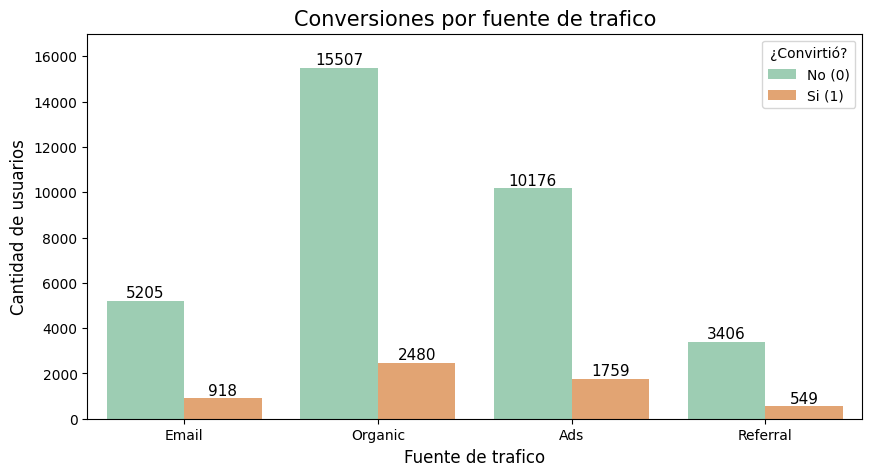

In [ ]:
plt.figure(figsize= (10,5))

ax= sns.countplot(data= df, x= "traffic_source", hue= "converted", palette= ["#95D5B2", "#F4A261"])
for bar in ax.patches:
    ax.text(x=bar.get_x() + bar.get_width() / 2,
           y= bar.get_height(),
           s= bar.get_height(),
           ha= "center",
           va= "bottom",
           fontsize= 11)

plt.title("Conversiones por fuente de trafico", fontsize= 15)
plt.xlabel("Fuente de trafico", fontsize= 12)
plt.ylabel("Cantidad de usuarios", fontsize= 12)
plt.ylim(0, 17000)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])
plt.show()

El gráfico revela una disparidad clara en volumen y eficiencia entre fuentes de tráfico. Organic es la fuente dominante en volumen (17,987 usuarios totales), seguida por Ads (11,935), pero Email, a pesar de menor volumen (6,123) destaca con la tasa de conversión más alta (cerca de $15\%$), sugiriendo mayor calidad o relevancia en su audiencia. Ads le sigue con mas o menos $14.7\%$, mientras que Organic y Referral presentan tasas similares ($13.8$ - $13.9\%$), indicando menor efectividad relativa. En perspectiva de negocio: aunque Organic genera más conversiones en números absolutos (2,480), Email genera más conversiones por usuario que llega, lo que podría reflejar diferencias en intención del usuario, segmentación de audiencia o calidad de targeting entre fuentes.

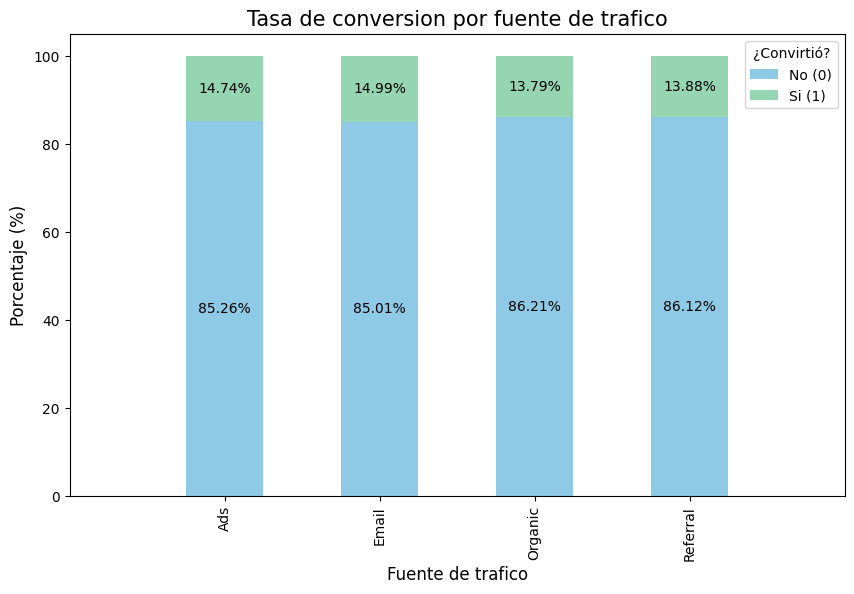

In [ ]:
ax= tabla_normalizada.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"])
plt.title("Tasa de conversion por fuente de trafico", fontsize= 15)
plt.ylabel("Porcentaje (%)", fontsize= 12)
plt.xlabel("Fuente de trafico", fontsize= 12)
ax.set_xlim(-1, 4)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()

    if height > 0:
        ax.annotate(
            f"{height:.2f}%",
            (x + width / 2, y + height / 2),
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )


Este gráfico de barras apiladas muestra el volumen de usuarios y su distribución de conversión por fuente de tráfico. Organic lidera en magnitud total ($≈ 17,500$ $usuarios$), pero Email sobresale por eficiencia de conversión, exhibiendo la proporción más alta de conversiones (verde) respecto a no conversiones (azul)—estimada en $≈ 15$ - $16\%$. Ads le sigue con una tasa moderada ($≈ 13-14\%$), mientras que Referral presenta el peor desempeño relativo (~13%). Aunque Organic genera muchas visitas, su tasa de conversión es relativamente baja comparada con Email, indicando que la calidad de la audiencia o la intención de compra varía significativamente según la fuente. Implicación estratégica: invertir más en Email y optimizar Ads podría ofrecer mejor ROI que escalar tráfico Organic.

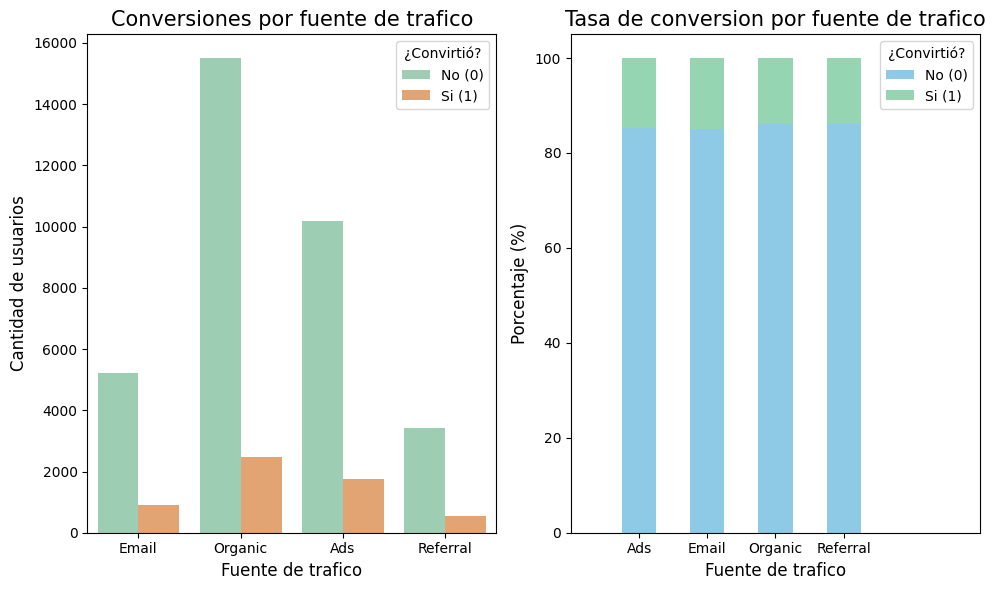

In [ ]:
fig, axes= plt.subplots(1,2, figsize= (18, 6))
#Grafico de barras
sns.countplot(data= df, x= "traffic_source", hue= "converted", palette= ["#95D5B2", "#F4A261"], ax= axes[0])
axes[0].set_title("Conversiones por fuente de trafico", fontsize= 15)
axes[0].set_xlabel("Fuente de trafico", fontsize= 12)
axes[0].set_ylabel("Cantidad de usuarios", fontsize= 12)
axes[0].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])

#Grafico de barras apiladas
tabla_normalizada.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"], ax= axes[1])
axes[1].set_title("Tasa de conversion por fuente de trafico", fontsize= 15)
axes[1].set_ylabel("Porcentaje (%)", fontsize= 12)
axes[1].set_xlabel("Fuente de trafico", fontsize= 12)
axes[1].set_xlim(-1, 5)
axes[1].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
axes[1].tick_params(axis= "x", rotation= 0)

plt.tight_layout()
plt.show()


### Relación entre el tipo de usuario y la conversión

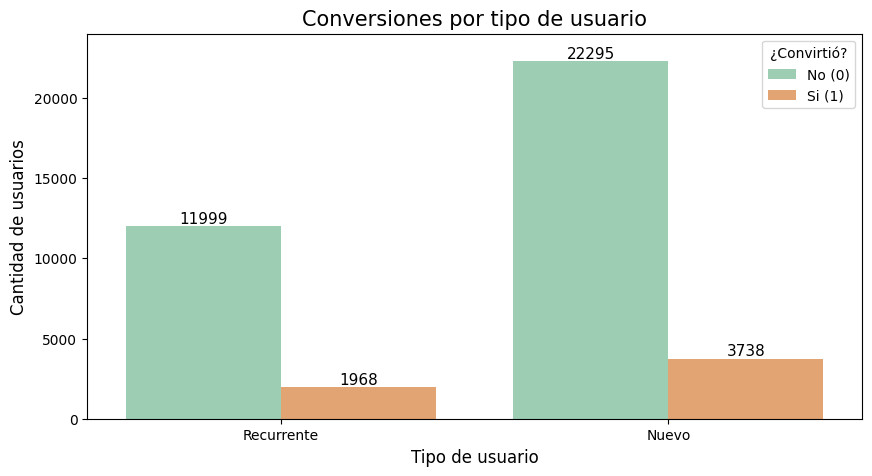

In [ ]:
plt.figure(figsize= (10, 5))
ax= sns.countplot(data= df, x= "user_type", hue= "converted", palette=["#95D5B2", "#F4A261"])
for bar in ax.patches:
    ax.text(x=bar.get_x() + bar.get_width() / 2,
    y= bar.get_height(),
    s= bar.get_height(),
    ha= "center",
    va= "bottom",
    fontsize= 11)
plt.title("Conversiones por tipo de usuario", fontsize= 15)
plt.xlabel("Tipo de usuario", fontsize= 12)
plt.ylabel("Cantidad de usuarios", fontsize= 12)
plt.ylim(0, 24000)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])
plt.show()


In [ ]:
tabla_user_type1= pd.crosstab(df["user_type"], df["converted"])
print("Tabla con valores absolutos: ")
print(tabla_user_type1)
tabla_usertype= pd.crosstab(df["user_type"], df["converted"], normalize= "index")*100
print("\nTabla con valores porcentuales: ")
print(tabla_usertype)

Tabla con valores absolutos: 
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Tabla con valores porcentuales: 
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


<Figure size 1000x500 with 0 Axes>

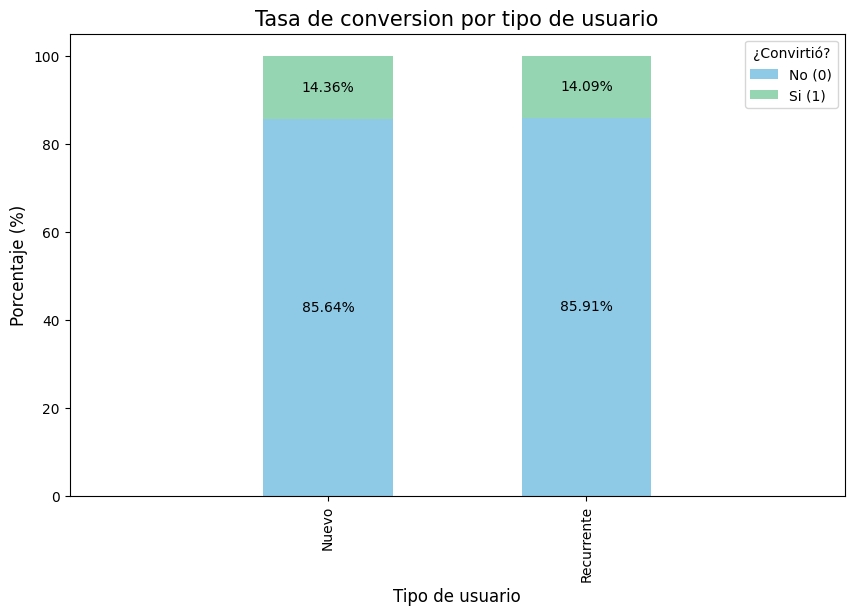

In [ ]:
tabla_usertype= pd.crosstab(df["user_type"], df["converted"], normalize= "index")*100
plt.figure(figsize= (10, 5))
ax= tabla_usertype.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"])
plt.title("Tasa de conversion por tipo de usuario", fontsize= 15)
plt.ylabel("Porcentaje (%)", fontsize= 12)
plt.xlabel("Tipo de usuario", fontsize= 12)
ax.set_xlim(-1, 2)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 0:
        porcentaje= height
        ax.annotate(
          f"{porcentaje:.2f}%",
          (x + width / 2, y + height / 2),
          ha="center",
          va="center",
          fontsize=10,
          color="black",
      )


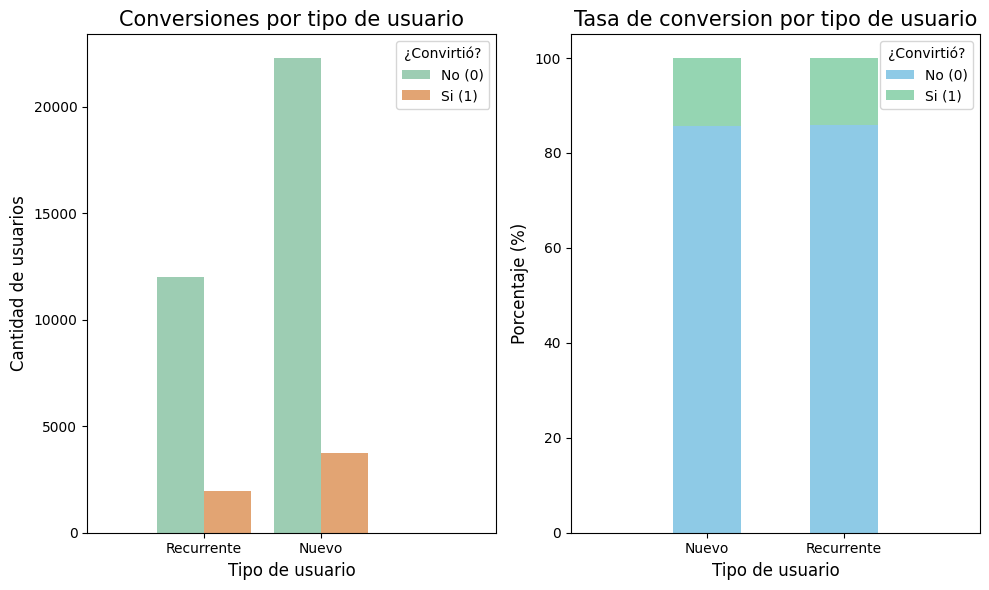

In [ ]:

fig, axes= plt.subplots(1,2, figsize= (18, 6))
#Grafico de barras
sns.countplot(data= df, x= "user_type", hue= "converted", palette= ["#95D5B2", "#F4A261"], ax= axes[0])
axes[0].set_title("Conversiones por tipo de usuario", fontsize= 15)
axes[0].set_xlabel("Tipo de usuario", fontsize= 12)
axes[0].set_ylabel("Cantidad de usuarios", fontsize= 12)
axes[0].set_xlim(-1, 2.5)
axes[0].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])

#Grafico de barras apiladas
tabla_usertype.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"], ax= axes[1])
axes[1].set_title("Tasa de conversion por tipo de usuario", fontsize= 15)
axes[1].set_ylabel("Porcentaje (%)", fontsize= 12)
axes[1].set_xlabel("Tipo de usuario", fontsize= 12)
axes[1].set_xlim(-1, 2)
axes[1].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
axes[1].tick_params(axis= "x", rotation= 0)

plt.tight_layout()
plt.show()



- **Volumen absoluto vs. Proporción:** Aunque el gráfico de la izquierda (Conversiones por tipo de usuario) muestra una mayor cantidad absoluta de usuarios nuevos convirtiendo en comparación con los recurrentes, esto se debe simplemente a que la muestra de usuarios nuevos es mucho más grande.
- **Tasa de conversión homogénea:** Al observar el gráfico de la derecha (Tasa de conversión por tipo de usuario), la proporción de conversión es prácticamente idéntica para ambos segmentos ($\approx 14.36\%$ en Nuevos vs. $\approx 14.09\%$ en Recurrentes), lo cual respalda visualmente el resultado del z-test ($p = 0.4644$).
- **Ausencia de causalidad:** Los datos muestran una correlación observacional sobre el comportamiento del usuario, pero no implican causalidad. Es decir, ser usuario "Nuevo" o "Recurrente" no es la causa directa de que una persona convierta o no; la tasa de conversión similar indica que el tipo de usuario no actúa como un factor determinante en la decisión de conversión.

### 6.3 Relación entre el tipo de pagina y la conversión

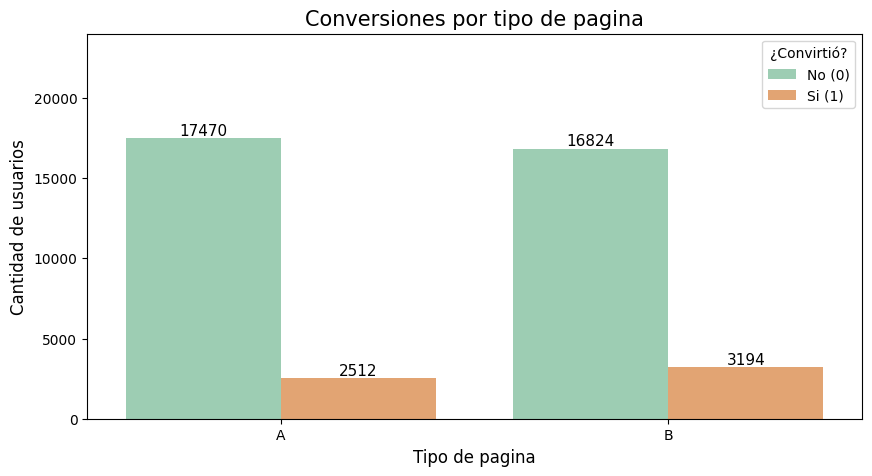

In [ ]:
plt.figure(figsize= (10, 5))
ax= sns.countplot(data= df, x= "landing", hue= "converted", palette=["#95D5B2", "#F4A261"])
for bar in ax.patches:
    ax.text(x=bar.get_x() + bar.get_width() / 2,
    y= bar.get_height(),
    s= bar.get_height(),
    ha= "center",
    va= "bottom",
    fontsize= 11)
plt.title("Conversiones por tipo de pagina", fontsize= 15)
plt.xlabel("Tipo de pagina", fontsize= 12)
plt.ylabel("Cantidad de usuarios", fontsize= 12)
plt.ylim(0, 24000)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])
plt.show()


<Figure size 1000x500 with 0 Axes>

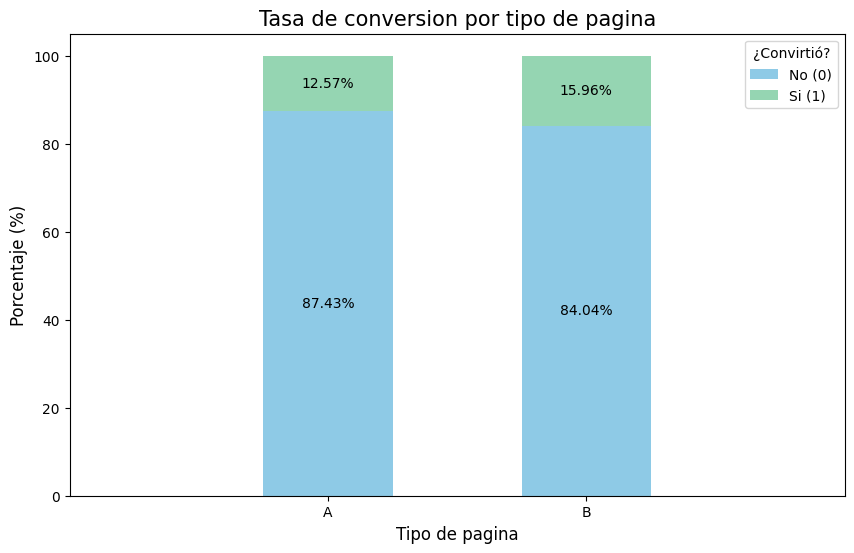

In [ ]:
tabla_usertype= pd.crosstab(df["landing"], df["converted"], normalize= "index")*100
plt.figure(figsize= (10, 5))
ax= tabla_usertype.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"])
plt.title("Tasa de conversion por tipo de pagina", fontsize= 15)
plt.ylabel("Porcentaje (%)", fontsize= 12)
plt.xlabel("Tipo de pagina", fontsize= 12)
ax.set_xlim(-1, 2)
plt.legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
plt.tick_params(axis= "x", rotation= 360)
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 0:
        porcentaje= height
        ax.annotate(
          f"{porcentaje:.2f}%",
          (x + width / 2, y + height / 2),
          ha="center",
          va="center",
          fontsize=10,
          color="black",
      )


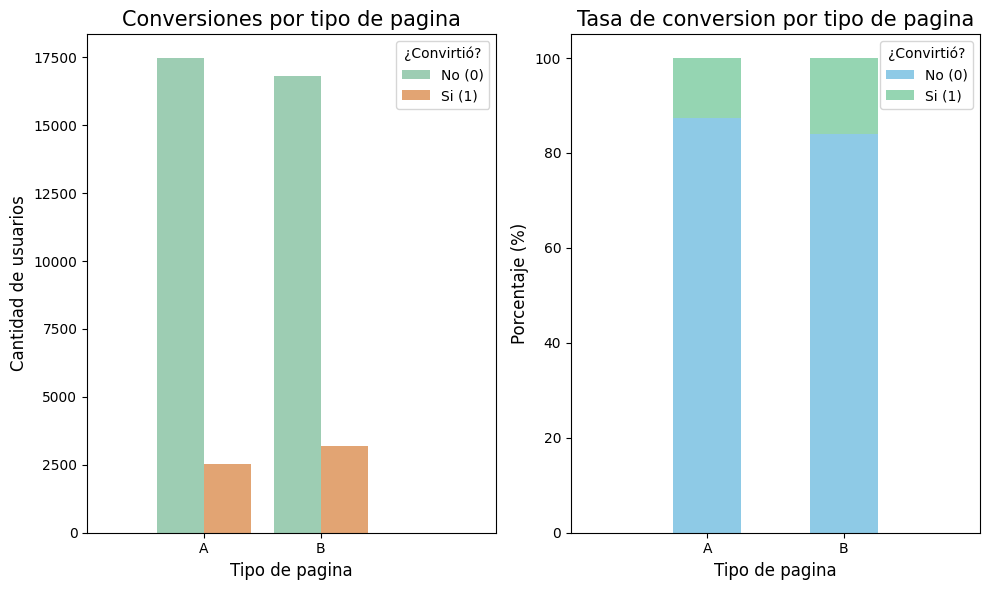

In [ ]:
fig, axes= plt.subplots(1,2, figsize= (18, 6))
#Grafico de barras
sns.countplot(data= df, x= "landing", hue= "converted", palette= ["#95D5B2", "#F4A261"], ax= axes[0])
axes[0].set_title("Conversiones por tipo de pagina", fontsize= 15)
axes[0].set_xlabel("Tipo de pagina", fontsize= 12)
axes[0].set_ylabel("Cantidad de usuarios", fontsize= 12)
axes[0].set_xlim(-1, 2.5)
axes[0].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"])

#Grafico de barras apiladas
tabla_usertype.plot(kind= "bar", stacked= True, figsize= (10,6), color= ["#8ecae6", "#95d5b2"], ax= axes[1])
axes[1].set_title("Tasa de conversion por tipo de pagina", fontsize= 15)
axes[1].set_ylabel("Porcentaje (%)", fontsize= 12)
axes[1].set_xlabel("Tipo de pagina", fontsize= 12)
axes[1].set_xlim(-1, 2)
axes[1].legend(title= "¿Convirtió?", labels= ["No (0)", "Si (1)"], loc= "upper right")
axes[1].tick_params(axis= "x", rotation= 0)

plt.tight_layout()
plt.show()


**Volumen absoluto vs. proporción**
La gráfica de volumen (izquierda) muestra que la página B genera un mayor conteo absoluto de conversiones ($≈3,200$) frente a A ($≈2,500$); la gráfica de proporción (derecha) confirma que este rendimiento superior se mantiene al normalizar por tráfico, alcanzando una tasa mayor ($≈16\%$ vs. $≈13\%$).
**Tipo de conversión**
No es homogénea: existe un claro diferencial de conversión entre las variantes a favor de la página B. La distribución de no-convertidos vs. convertidos cambia entre ambas variantes, mostrando una variación relativa superior a 2 puntos porcentuales en la tasa global.3.
**Ausencia de causalidad**
El mayor rendimiento de la página B es una correlación observacional. Sin controlar variables de confusión (origen del tráfico, dispositivo, o segmentación previa) mediante un test A/B y una prueba de hipótesis que confirme la significancia estadística ($p\text{-valor}$), no se puede asumir que el diseño de la página sea la causa directa de la mejora.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?

La pagina $B$.

- ¿Qué canales de tráfico son más efectivos para generar conversiones?

Al observar las tasas de conversión por canal, las diferencias son muy pequeñas (Email con $14.99\%$ y Ads con $14.73\%$ frente a Organic con $13.79\%$).

- ¿Existen diferencias significativas según el tipo de usuario?

Si, estadisticamente hablando los usuarios nuevos constituyen alrededor de un $67\%$ del volumen total y generan proporcionalmente mas conversiones.


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

**Observación 1 - Diferencia de magnitud:**

La Página B registra un gasto promedio de $\$68.75$ por usuario conversor, mientras que la Página A alcanza $\$61.09$. Esto representa una diferencia de $\$7.66$ USD ($12.5% más alto$) a favor de la Página B.

**Observación 2 - Validación estadística:**

El **estadístico** $t$  $de$ $-9.3656$ con $valor$ $p ≈ 0.00000000$ indica que esta diferencia es **estadísticamente significativa** al nivel de confianza más estricto ($p < 0.001$). La probabilidad de que esta diferencia ocurra por azar es prácticamente nula.

**Interpretación:**

La **prueba estadística demuestra que existe una diferencia real y medible** en el gasto promedio entre ambas variantes. Sin embargo, **esta prueba no establece causalidad:** no podemos afirmar que la Página B causa mayores gastos. La diferencia podría deberse a factores como el perfil de usuarios, el timing de la prueba, variables externas no controladas, u otros elementos no capturados en este análisis.


<br>

**Tasa de conversión:**

**Observación 1 - Volumen de conversiones:**

La Página A generó **2,512 conversiones** mientras que la Página B logró **3,194 conversiones**, representando **681 conversiones adicionales** ($27.1\%$ $más$ $alto$) en la Página B.

**Observación 2 - Consistencia en performance:**

Ambas variantes demostraron capacidad de conversión significativa con volúmenes importantes. La Página B no solo mostró mayor valor promedio sino también un mayor volumen absoluto de usuarios que completaron la acción deseada.

**Interpretación:**

Los datos sugieren que la **Página B presenta un desempeño superior tanto en conversiones absolutas como en valor monetario generado**. No obstante, como con cualquier test estadístico, debemos enfatizar que **esta comparación no prueba causalidad**. La mayor tasa de conversión en B podría estar influenciada por variables no controladas, diferencias en la audiencia expuesta, factores temporales, o elementos externos. Se recomienda replicar el test con controles adicionales antes de atribuir el desempeño directamente a las características de la Página B.


---
---


#### 📊 **Segmentación por fuente de tráfico**
**Observación 1 - Concentración desproporcionada del tráfico:**

La segmentación revela que **Organic concentra** $60.9\%$ **del tráfico total** ($17,987$ $usuarios$), mientras que Ads representa $29.7\%$ ($11,935$), Email $10.1\%$ ($6,123$) y Referral $9.5\%$ ($3,955$). A pesar de que Email y Referral generan volúmenes similares, **Organic es el motor absoluto del tráfico**, siendo **4.5 veces más grande que Referral**.

**Observación 2 - Heterogeneidad en la composición de usuarios:**

Cada fuente atrae perfiles de usuarios con características distintas. La tabla normalizada muestra que la **distribución proporcional de conversiones varía ligeramente por canal**, indicando que cada fuente trae usuarios con diferentes propensiones a convertir según su origen.

**Interpretación:**

La estrategia de adquisición actual depende fuertemente de Organic, generando **un riesgo de concentración significativo**. Aunque Organic es eficiente, las fuentes secundarias (Ads, Email, Referral) operan a escalas considerablemente menores. Esta segmentación sugiere **oportunidades de diversificación:** invertir en maduración de canales secundarios podría reducir vulnerabilidad a cambios en algoritmos de búsqueda o disponibilidad de canales.

**Tasa de conversion por fuente**

**Observación 1 - Variabilidad moderada en tasas de conversión:**

Las tasas de conversión muestran diferencias leves pero consistentes:

Email: $15.02\%$ (mayor)

Ads: $14.75\%$

Referral: $13.88\%$

Organic: $13.78\%$ (menor)

La diferencia entre el canal más eficiente (Email) y el menos eficiente (Organic) es de apenas **1.24 puntos porcentuales**, indicando **homogeneidad relativa en eficiencia**.

**Observación 2 - Significancia estadística confirmada:**

La **prueba Chi-cuadrado ($χ² = 8.66$, $p-value = 0.034$)** con **3 grados de libertad** confirma una asociación estadísticamente significativa ($p < 0.05$) entre fuente de tráfico y conversión. Sin embargo, el análisis de frecuencias esperadas revela que las **diferencias observadas son sutiles**, con desviaciones pequeñas respecto a lo esperado.

**Interpretación:**

Aunque la prueba estadística **demuestra que existe una relación real entre fuente y tasa de conversión** (no debida al azar), **es crítico aclarar que esto no establece causalidad**. No podemos afirmar que Email "causa" conversiones más altas que Organic.

**Las diferencias observadas podrían explicarse por:**

- **·Características intrínsecas del usuario:** Usuarios de Email pueden estar más comprometidos (ya están en la base de datos), mientras que Organic podría incluir visitantes ocasionales de primera vez.
- **·Intención de compra:** Referral podría atraer usuarios con menor intención inmediata de compra
- **·Timing de exposición:** Email permite control temporal de mensajería; Organic es asincrónico
- **·Variables no medidas:** Dispositivo, historial previo, contexto de navegación

---
---


#### 📊 **Segmentación por tipo de usuario**
**1. Tipo de usuario que convirtio**

**Observación 1:**

El volumen total de tráfico está marcadamente inclinado hacia usuarios Nuevos ($26,033$ usuarios) en comparación con los Recurrentes ($13,967$ usuarios).

**Observación 2:**

En términos absolutos, el grupo de usuarios Nuevos generó casi el doble de conversiones ($3,738$ conversiones) respecto al grupo Recurrente ($1,968$ conversiones).

**Interpretación:**

La diferencia en el número total de conversiones no responde a un mayor compromiso del usuario nuevo, sino simplemente a la desproporción en el tamaño de las muestras (el tráfico nuevo es un $86\%$ mayor que el recurrente).

**2. Tasa de conversión por tipo de usuario**

**Observación 1:**

Al calcular la tasa relativa, la conversión es de $14.36\%$ para usuarios Nuevos y de $14.09\%$ para Recurrentes.

**Observación 2:**

La prueba estadistica de hipótesis (z-test) arrojó un estadístico $z = 0.7316$ y un valor p de $p = 0.4644$ ($p > 0.05$).

**Interpretación:**

No existe evidencia estadística suficiente para afirmar que la tasa de conversión varíe según la antigüedad o tipo de usuario; la variación de $0.27\%$ se atribuye únicamente al azar o ruido muestral.Nota sobre



[[  Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.  ]]


---
---


#### 💡 **Recomendaciones de negocio:**

1. $Replicar$ $y$ $Validar$ $el$ $Desempeño$ $de$ $Página$ $B$ $Antes$ $de$ $Implementación$ $a$ $Escala$

**Fundamento:** Los datos muestran que Página B tiene $27.1\%$ más conversiones y $12.5\%$ mayor gasto promedio, con significancia estadística ($p < 0.00000000$). Sin embargo, **estos tests estadísticos demuestran que existe una diferencia real, pero NO prueban que Página B CAUSA ese desempeño superior**.

**¿Por qué esta distinción es crítica?**
La diferencia observada podría deberse a:

- Usuarios expuestos a cada página en diferente contexto (hora del día, dispositivo, fuente de tráfico)
- Timing temporal no controlado (estacionalidad, campanhas externas simultáneas)
- Factores no medidos (historial previo del usuario, intención de compra, estado del producto)

**Acciones concretas:**

- **Lanzar segundo test A/B** con nuevas cohortes de usuarios en período diferente (mínimo 2-4 semanas, idealmente en estación diferente)
- **Mantener control A** para descartar que la ganancia sea por degradación de A, no mejora de B
- **Documentar todas las variables diferentes** entre A y B (color, copy, diseño, CTA) para futuro análisis de drivers
- **Definir MDE (Minimum Detectable Effect)** antes del test: ¿Qué magnitud de ganancia justifica el cambio? Si el segundo test muestra 5% en lugar de 27%, ¿aún es decisivo?

**Impacto esperado:** Validar si la ganancia es atribuible a cambios de página o a confounders; evitar implementación de cambio inefectivo a escala

**Costo de no hacer esto:** Implementar Página B a 100% de tráfico, descubrir que la ganancia no persiste, y haber perdido conversiones reales

2. $Diseñar$ $Estrategia$ $de$ $Diversificación$ $de$ $Tráfico$ $Reconociendo$ $que$ $Fuente$ $NO$ $CAUSA$ $Diferencias$ $de$ $Conversión$

**Fundamento:** Los datos muestran que Organic concentra $60.9\%$ del tráfico, mientras que Email ($15.02\%$), Ads ($14.75\%$) y Referral ($13.88\%$) tienen tasas de conversión prácticamente idénticas o ligeramente superiores. La prueba Chi-cuadrado ($χ²$ $=$8.66$, $p$ = 0.034$) es estadísticamente significativa, **pero esto NO significa que una fuente de tráfico CAUSE conversiones mejores o peores que otra**.

**¿Por qué esta distinción es crítica?**
Las diferencias en tasas de conversión observadas entre canales NO pueden atribuirse a "Email es mejor que Organic". Podrían explicarse por:

- **Diferentes perfiles de usuario:** Email llega a usuarios ya comprometidos (ya están en lista); Organic es visitantes de primer contacto con menor intención inmediata
- **Timing de exposición:** Email permite control temporal de mensaje; Organic es asincrónico
- **Intención implícita:** Usuarios en Email campañas ya eligieron recibir contenido; usuarios Organic pueden ser navegación casualista
- **Fricción diferencial:** Cada fuente tiene obstáculos distintos antes de conversión

**Acciones concretas:**

- **Diversificar por volumen, no por tasa:** Aumentar inversión en Ads y Email NO porque "convierten mejor", sino porque tienen igual eficiencia con menor escala, permitiendo crecimiento sin saturación
- **Crear control experimental por fuente:** Para cada canal secundario (Ads, Email), mantener grupo control sin intervención para medir incrementalidad real versus canibalization
- **Segmentar análisis post-conversión:** Comparar LTV, repeat purchase rate y margin por fuente de tráfico—no solo conversión inicial. La verdadera superioridad de un canal se ve en comportamiento post-conversión, no en el acto inicial
- **Evitar atribución simplista:** No asignar 100% del crédito de conversión a la fuente última; considerar que múltiples touchpoints pueden haber influido (last-click vs. multi-touch attribution)

**Impacto esperado:**

Reducir riesgo de dependencia de Organic (60.9% → ≈40-50% en 12 meses)
Aumentar resiliencia ante cambios de algoritmo de búsqueda
Validar verdaderamente cuáles canales generan valor incremental versus canibalization

**Costo de no hacer esto:** Escalar Ads o Email asumiendo que su "mejor" tasa de conversión se mantendrá a mayor volumen, descubrir que la diferencia desaparece (o se invierte) cuando se controlan factores de confounding, y haber malgastado presupuesto